# OP'26 Analytics — Agentic AI Dynamic Tariff Optimization for EV Charging Networks

**Society of Business Open Project 2026**

This notebook contains the complete end-to-end pipeline:

| Stage | Content |
|---|---|
| 0 | Setup & Data Loading |
| 1 | Data Preprocessing & Feature Engineering |
| 2 | Exploratory Data Analysis |
| 3 | Demand Prediction Agent |
| 4 | Tariff Pricing Agent |
| 5 | Monitoring & Learning Agent |

**Datasets:** ACN-Data (Caltech/JPL, 14,999 sessions) + UrbanEV/ST-EVCDP (Shenzhen, 2.1M panel observations)

**Key assumption:** Revenue simulated at ₹15/kWh baseline (ACN has no price); UrbanEV ¥ prices used only as elasticity proxy.


---

# Stage 0: Setup & Data Loading


# Notebook 00: Setup & Data Loading

**OP'26 Analytics — Agentic AI Dynamic Tariff Optimization for EV Charging**

This notebook verifies the environment and loads both datasets:
- **ACN-Data**: 30k+ Caltech/JPL charging sessions (Apr–Dec 2018)
- **UrbanEV (ST-EVCDP)**: Shenzhen, 5-min interval data across ~247 district grids (Jun–Dec 2022)

All subsequent notebooks import from `src/` helpers built here.

In [1]:
import sys
from pathlib import Path

# Ensure src/ is on the path
SRC = Path('..') / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import sklearn
import seaborn as sns

print(f'pandas  : {pd.__version__}')
print(f'numpy   : {np.__version__}')
print(f'sklearn : {sklearn.__version__}')
print(f'matplotlib: {matplotlib.__version__}')

pandas  : 3.0.3
numpy   : 2.4.6
sklearn : 1.9.0
matplotlib: 3.10.9


## 1. Load ACN-Data

In [2]:
from io_utils import load_acn

acn_raw = load_acn()
print(f'ACN shape: {acn_raw.shape}')
print(f'Columns  : {list(acn_raw.columns)}')
acn_raw.head(3)

ACN shape: (16304, 26)
Columns  : ['_meta', 'end', 'min_kWh', 'site', 'start', '_items', '_id', 'clusterID', 'connectionTime', 'disconnectTime', 'doneChargingTime', 'kWhDelivered', 'sessionID', 'siteID', 'spaceID', 'stationID', 'timezone', 'userID', 'WhPerMile', 'kWhRequested', 'milesRequested', 'minutesAvailable', 'modifiedAt', 'paymentRequired', 'requestedDeparture', 'userID.1']


,_meta,end,min_kWh,site,start,_items,_id,clusterID,connectionTime,disconnectTime,...,timezone,userID,WhPerMile,kWhRequested,milesRequested,minutesAvailable,modifiedAt,paymentRequired,requestedDeparture,userID.1
0,NaN,NaN,NaN,caltech,NaN,NaN,5bc90cb9f9af8b0d7fe77cd2,39.0,2018-04-25 11:08:04+00:00,2018-04-25 13:20:10+00:00,...,America/Los_Angeles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,5bc90cb9f9af8b0d7fe77cd3,39.0,2018-04-25 13:45:10+00:00,2018-04-26 00:56:16+00:00,...,America/Los_Angeles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,5bc90cb9f9af8b0d7fe77cd4,39.0,2018-04-25 13:45:50+00:00,2018-04-25 23:04:45+00:00,...,America/Los_Angeles,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Valid session rows (non-null kWh)
acn = acn_raw[acn_raw['kWhDelivered'].notna() & (acn_raw['kWhDelivered'] > 0)].copy()
print(f'Valid sessions: {len(acn):,}')
print(f'Date range   : {acn["connectionTime"].min()} → {acn["connectionTime"].max()}')
print(f'Sites        : {acn["siteID"].unique()}')
acn[['kWhDelivered','connectionTime','disconnectTime','doneChargingTime','stationID']].describe()

Valid sessions: 14,999
Date range   : 2018-04-25 11:08:04+00:00 → 2018-12-16 03:01:46+00:00
Sites        : [2.]


,kWhDelivered
count,14999.000000
mean,9.002466
std,7.055848
min,0.501000
25%,4.008500
50%,7.435000
75%,13.204000
max,69.373000


## 2. Load UrbanEV Panel

In [4]:
from io_utils import load_urbanev_panel, load_urbanev_info

uev = load_urbanev_panel()
print(f'UrbanEV shape: {uev.shape}')
print(f'Columns: {list(uev.columns)}')
print(f'Grids: {uev["grid_id"].nunique()}')
print(f'Timesteps: {uev["timestamp"].nunique()}')
print(f'Date range: {uev["datetime"].min()} → {uev["datetime"].max()}')
uev.head(3)

UrbanEV shape: (2134080, 15)
Columns: ['timestamp', 'grid_id', 'occupancy', 'volume', 'duration', 'price', 'datetime', 'count', 'fast_count', 'slow_count', 'area', 'lon', 'la', 'CBD', 'dynamic_pricing']
Grids: 247
Timesteps: 8640
Date range: 2022-06-19 00:00:00 → 2022-07-18 23:55:00


,timestamp,grid_id,occupancy,volume,duration,price,datetime,count,fast_count,slow_count,area,lon,la,CBD,dynamic_pricing
0,1,1000,60,16.197222,3.157778,0.894267,2022-06-19 00:00:00,193,0,193,3.08,114.2695,22.72019,0,0
1,2,1000,60,24.791667,4.833333,0.894267,2022-06-19 00:05:00,193,0,193,3.08,114.2695,22.72019,0,0
2,3,1000,60,24.791667,4.833333,0.894267,2022-06-19 00:10:00,193,0,193,3.08,114.2695,22.72019,0,0


In [5]:
print('=== UrbanEV key stats ===')
print(uev[['occupancy','volume','duration','price']].describe().round(3))
print(f'\nGrids with dynamic_pricing=1: {uev["dynamic_pricing"].sum() // uev["timestamp"].nunique()}')
print(f'CBD grids: {uev["CBD"].sum() // uev["timestamp"].nunique()}')

=== UrbanEV key stats ===
         occupancy       volume     duration        price
count  2134080.000  2134080.000  2134080.000  2134080.000
mean        21.902       36.678        1.473        0.959
std         24.800      101.893        1.803        0.181
min          0.000        0.000        0.000        0.250
25%          5.000        2.333        0.333        0.850
50%         13.000        7.000        0.833        0.984
75%         30.000       23.333        1.862        1.073
max        220.000     1492.500       17.083        1.470

Grids with dynamic_pricing=1: 57
CBD grids: 62


## 3. Cache to Parquet

Cache processed copies so later notebooks skip the xlsx/csv parse step.

In [6]:
OUT = Path('..') / 'data_processed'
OUT.mkdir(exist_ok=True)

# ACN — save only valid sessions, stringify tz-aware timestamps for parquet compat
acn_save = acn.copy()
for col in ['connectionTime','disconnectTime','doneChargingTime']:
    if col in acn_save.columns:
        acn_save[col] = acn_save[col].astype(str)
acn_save.to_parquet(OUT / 'acn_raw.parquet', index=False)

uev.to_parquet(OUT / 'urbanev_panel.parquet', index=False)
print('Cached to data_processed/')
print(f'  acn_raw.parquet      : {(OUT/"acn_raw.parquet").stat().st_size/1e6:.1f} MB')
print(f'  urbanev_panel.parquet: {(OUT/"urbanev_panel.parquet").stat().st_size/1e6:.1f} MB')

Cached to data_processed/
  acn_raw.parquet      : 1.0 MB
  urbanev_panel.parquet: 12.8 MB


---

# Stage 1: Data Preprocessing & Feature Engineering


# Notebook 01: Data Preprocessing & Feature Engineering

Builds the unified analytical base from both datasets with all PS-required engineered features.

**Assumption log (documented here as required by PS):**
- Revenue is simulated as `tariff × kWhDelivered` against the ₹15/kWh fixed baseline (ACN has no price field).
- UrbanEV ¥/kWh prices are used solely as a price elasticity proxy; the coefficient is treated as an order-of-magnitude estimate, not a calibrated INR elasticity.
- Utilization = Charging Time / Total Available Time (PS definition); for UrbanEV, occupancy / total pile count.
- Missing kWh rows in ACN (~1,305) are dropped (Excel trailing rows with no session data).
- Missing values in UrbanEV lag features arise from the start of each grid's time series; they are left as NaN and handled natively by HistGradientBoosting.

In [7]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..') / 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from io_utils import load_acn, load_urbanev_panel
from features import build_acn_features, build_acn_station_hour, build_urbanev_features, BASELINE_TARIFF

OUT_DATA = Path('..') / 'data_processed'
OUT_FIG  = Path('..') / 'outputs' / 'figures'
OUT_FIG.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
print('Libraries ready')

Libraries ready


## 1. ACN — Session-Level Features

In [8]:
acn_raw = load_acn()
acn_valid = acn_raw[acn_raw['kWhDelivered'].notna() & (acn_raw['kWhDelivered'] > 0)].copy()
print(f'Valid ACN sessions: {len(acn_valid):,}')

acn = build_acn_features(acn_valid)
print(f'Features added: {[c for c in acn.columns if c not in acn_valid.columns]}')

# Summary: missing values
print('\nMissing values in key derived columns:')
for c in ['session_duration_h','charging_duration_h','idle_time_h','hour','dow','revenue_baseline']:
    print(f'  {c}: {acn[c].isna().sum()}')

Valid ACN sessions: 14,999
Features added: ['session_duration_h', 'charging_duration_h', 'idle_time_h', 'valid', 'revenue_baseline', 'hour', 'dow', 'weekend', 'date', 'period']

Missing values in key derived columns:
  session_duration_h: 0
  charging_duration_h: 8
  idle_time_h: 8
  hour: 0
  dow: 0
  revenue_baseline: 0


In [9]:
print('=== ACN session-level feature summary ===')
print(acn[['session_duration_h','charging_duration_h','idle_time_h','kWhDelivered','revenue_baseline']].describe().round(3))

=== ACN session-level feature summary ===
       session_duration_h  charging_duration_h  idle_time_h  kWhDelivered  \
count           14999.000            14991.000    14991.000     14999.000   
mean                5.924                3.236        2.690         9.002   
std                 6.459                3.185        5.396         7.056   
min                 0.088               -0.689       -0.017         0.501   
25%                 2.025                1.272        0.001         4.008   
50%                 4.764                2.242        0.740         7.435   
75%                 8.730                4.244        4.187        13.204   
max               245.269              104.428      156.121        69.373   

       revenue_baseline  
count         14999.000  
mean            135.037  
std             105.838  
min               7.515  
25%              60.128  
50%             111.525  
75%             198.060  
max            1040.595  


## 2. ACN — Station × Hour Aggregation

In [10]:
acn_hourly = build_acn_station_hour(acn)
print(f'Station-hour panel: {acn_hourly.shape}')
print(f'Stations: {acn_hourly["stationID"].nunique()}')
print(f'Date range: {acn_hourly["slot"].min()} → {acn_hourly["slot"].max()}')
acn_hourly[['sessions','kWh_delivered','utilization_rate','queue_proxy','revenue_session']].describe().round(3)

Station-hour panel: (14839, 18)
Stations: 54
Date range: 2018-04-25 11:00:00+00:00 → 2018-12-16 03:00:00+00:00


,sessions,kWh_delivered,utilization_rate,queue_proxy,revenue_session
count,14839.000,14839.000,14831.000,14839.000,14839.000
mean,1.007,9.062,0.931,0.606,135.926
std,0.089,7.052,0.185,0.230,105.782
min,1.000,0.501,0.000,0.250,7.515
25%,1.000,4.082,1.000,0.500,61.238
50%,1.000,7.512,1.000,0.500,112.680
75%,1.000,13.208,1.000,0.500,198.120
max,4.000,69.373,1.000,1.000,1040.595


In [11]:
# Missing values in lag features (expected at start of each station's series)
for c in ['lag_1h_sessions','lag_24h_sessions','rolling_7d_sessions']:
    print(f'{c} NaN: {acn_hourly[c].isna().sum()} / {len(acn_hourly)}')

lag_1h_sessions NaN: 54 / 14839
lag_24h_sessions NaN: 1262 / 14839
rolling_7d_sessions NaN: 54 / 14839


## 3. UrbanEV — Feature Engineering

In [12]:
uev_raw = load_urbanev_panel()
print(f'UrbanEV raw: {uev_raw.shape}')

uev = build_urbanev_features(uev_raw)
print(f'UrbanEV with features: {uev.shape}')
new_cols = [c for c in uev.columns if c not in uev_raw.columns]
print(f'New feature columns: {new_cols}')

UrbanEV raw: (2134080, 15)


UrbanEV with features: (2134080, 42)
New feature columns: ['utilization_rate', 'occupancy_density', 'revenue_proxy', 'energy_cost_per_kwh', 'hour', 'dow', 'weekend', 'is_peak', 'is_off_peak', 'period', 'lag_1_occupancy', 'lag_12_occupancy', 'lag_288_occupancy', 'roll_2h_occupancy', 'lag_1_volume', 'lag_12_volume', 'lag_288_volume', 'roll_2h_volume', 'lag_1_price', 'lag_12_price', 'lag_288_price', 'roll_2h_price', 'lag_1_utilization_rate', 'lag_12_utilization_rate', 'lag_288_utilization_rate', 'roll_2h_utilization_rate', 'congested']


In [13]:
print('=== UrbanEV engineered feature summary ===')
print(uev[['utilization_rate','occupancy_density','revenue_proxy','congested']].describe().round(4))

=== UrbanEV engineered feature summary ===
       utilization_rate  occupancy_density  revenue_proxy     congested
count      2.134080e+06       2.134080e+06   2.134080e+06  2.134080e+06
mean       2.802000e-01       1.021530e+01   2.999740e+01  1.020000e-02
std        1.760000e-01       1.262920e+01   7.330480e+01  1.007000e-01
min        0.000000e+00       0.000000e+00   0.000000e+00  0.000000e+00
25%        1.515000e-01       1.910800e+00   2.275000e+00  0.000000e+00
50%        2.500000e-01       5.921100e+00   6.809000e+00  0.000000e+00
75%        3.779000e-01       1.428570e+01   2.170000e+01  0.000000e+00
max        1.000000e+00       1.552632e+02   1.026873e+03  1.000000e+00


In [14]:
print('Missing values in lag features (expected: ~288 per grid at series start):')
for c in ['lag_1_occupancy','lag_12_occupancy','lag_288_occupancy','lag_288_utilization_rate']:
    print(f'  {c}: {uev[c].isna().sum():,}')

Missing values in lag features (expected: ~288 per grid at series start):
  lag_1_occupancy: 247
  lag_12_occupancy: 2,964
  lag_288_occupancy: 71,136
  lag_288_utilization_rate: 71,136


## 4. Utilization Rate Verification

Key PS metric: Charger Utilization Rate = Charging Time / Total Available Time.

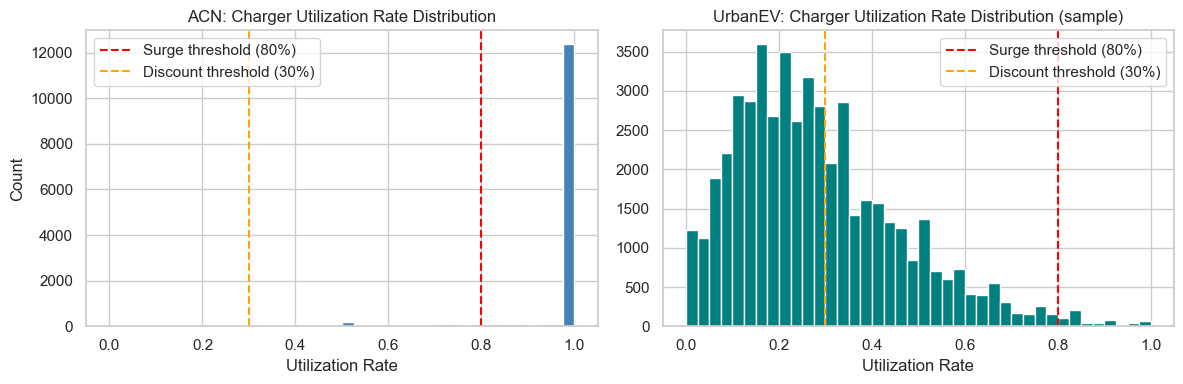

Pricing implication: both datasets show bimodal patterns — many near-zero slots and many near-full slots, confirming the case for dynamic pricing vs. a flat ₹15 tariff.


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ACN
axes[0].hist(acn_hourly['utilization_rate'].dropna(), bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(0.8, color='red', linestyle='--', label='Surge threshold (80%)')
axes[0].axvline(0.3, color='orange', linestyle='--', label='Discount threshold (30%)')
axes[0].set_title('ACN: Charger Utilization Rate Distribution')
axes[0].set_xlabel('Utilization Rate')
axes[0].set_ylabel('Count')
axes[0].legend()

# UrbanEV
sample_uev = uev[uev['utilization_rate'].notna()]['utilization_rate'].sample(50000, random_state=42)
axes[1].hist(sample_uev, bins=40, color='teal', edgecolor='white')
axes[1].axvline(0.8, color='red', linestyle='--', label='Surge threshold (80%)')
axes[1].axvline(0.3, color='orange', linestyle='--', label='Discount threshold (30%)')
axes[1].set_title('UrbanEV: Charger Utilization Rate Distribution (sample)')
axes[1].set_xlabel('Utilization Rate')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_FIG / 'utilization_distributions.png', dpi=150)
plt.show()
print('Pricing implication: both datasets show bimodal patterns — many near-zero slots and many near-full slots, confirming the case for dynamic pricing vs. a flat ₹15 tariff.')

## 5. Cache Processed Data

In [16]:
# ACN session-level
acn_save = acn.copy()
for col in ['connectionTime','disconnectTime','doneChargingTime','ui_requestedDeparture']:
    if col in acn_save.columns:
        acn_save[col] = acn_save[col].astype(str)
acn_save['period'] = acn_save['period'].astype(str)
acn_save.to_parquet(OUT_DATA / 'acn_sessions_featured.parquet', index=False)

# ACN station-hour
acn_h_save = acn_hourly.copy()
acn_h_save['slot'] = acn_h_save['slot'].astype(str)
acn_h_save['period'] = acn_h_save.get('period', pd.Series([''] * len(acn_h_save))).astype(str)
acn_h_save.to_parquet(OUT_DATA / 'acn_station_hour.parquet', index=False)

# UrbanEV
uev_save = uev.copy()
uev_save['period'] = uev_save['period'].astype(str)
uev_save.to_parquet(OUT_DATA / 'urbanev_featured.parquet', index=False)

print('Saved:')
for f in ['acn_sessions_featured.parquet','acn_station_hour.parquet','urbanev_featured.parquet']:
    sz = (OUT_DATA/f).stat().st_size / 1e6
    print(f'  {f}: {sz:.1f} MB')

Saved:
  acn_sessions_featured.parquet: 1.3 MB
  acn_station_hour.parquet: 0.4 MB
  urbanev_featured.parquet: 52.2 MB


---

# Stage 2: Exploratory Data Analysis


# Notebook 02: Exploratory Data Analysis

All visualisations are insight-driven, well-labelled, and tied directly to pricing implications.

Key questions answered here:
1. How does demand vary intraday, by day-of-week, and across peak/shoulder/off-peak periods?
2. What are the differences between ACN (workplace fleet) and UrbanEV (public urban) charging?
3. Where is utilisation consistently high (congestion risk) or low (underutilisation)?
4. What is the preliminary price–demand relationship in UrbanEV?

In [17]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..') / 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

OUT_DATA = Path('..') / 'data_processed'
OUT_FIG  = Path('..') / 'outputs' / 'figures'
OUT_FIG.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
COLORS = {'peak': '#d62728', 'shoulder': '#ff7f0e', 'off_peak': '#2ca02c',
          'acn': '#1f77b4', 'uev': '#17becf'}

acn_h = pd.read_parquet(OUT_DATA / 'acn_station_hour.parquet')
acn_h['slot'] = pd.to_datetime(acn_h['slot'], utc=True)
uev = pd.read_parquet(OUT_DATA / 'urbanev_featured.parquet')
uev['datetime'] = pd.to_datetime(uev['datetime'])

print(f'ACN station-hour: {acn_h.shape}')
print(f'UrbanEV featured: {uev.shape}')

ACN station-hour: (14839, 19)
UrbanEV featured: (2134080, 42)


## 1. Intraday Demand Patterns

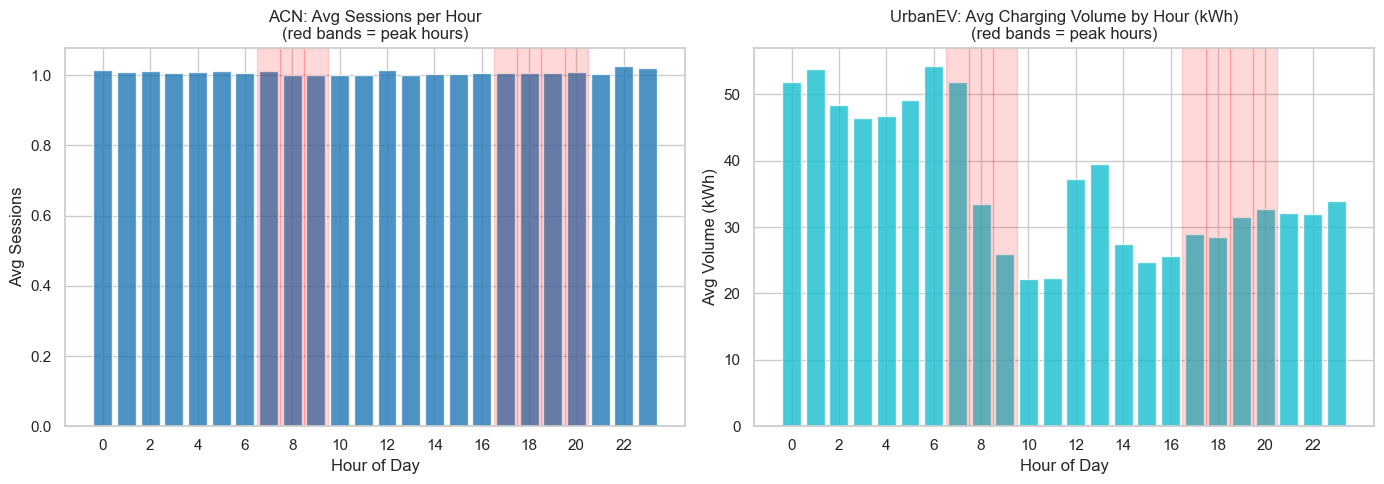

Pricing implication: Demand concentrates in morning and evening peaks.
Surge pricing during peak hours can redistribute load and capture higher revenue.
Discounts in the 0–6 AM window can activate dormant charger capacity.


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ACN: sessions by hour
acn_hour = acn_h.groupby('hour')['sessions'].mean()
axes[0].bar(acn_hour.index, acn_hour.values, color=COLORS['acn'], alpha=0.8)
for h in [7, 8, 9, 17, 18, 19, 20]:
    axes[0].axvspan(h-0.5, h+0.5, alpha=0.15, color='red')
axes[0].set_title('ACN: Avg Sessions per Hour\n(red bands = peak hours)', fontsize=12)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Avg Sessions')
axes[0].set_xticks(range(0, 24, 2))

# UrbanEV: avg volume by hour
uev_hour = uev.groupby('hour')['volume'].mean()
axes[1].bar(uev_hour.index, uev_hour.values, color=COLORS['uev'], alpha=0.8)
for h in [7, 8, 9, 17, 18, 19, 20]:
    axes[1].axvspan(h-0.5, h+0.5, alpha=0.15, color='red')
axes[1].set_title('UrbanEV: Avg Charging Volume by Hour (kWh)\n(red bands = peak hours)', fontsize=12)
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Avg Volume (kWh)')
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig(OUT_FIG / 'eda_intraday.png', dpi=150)
plt.show()
print('Pricing implication: Demand concentrates in morning and evening peaks.\nSurge pricing during peak hours can redistribute load and capture higher revenue.\nDiscounts in the 0–6 AM window can activate dormant charger capacity.')

## 2. Weekday vs Weekend Patterns

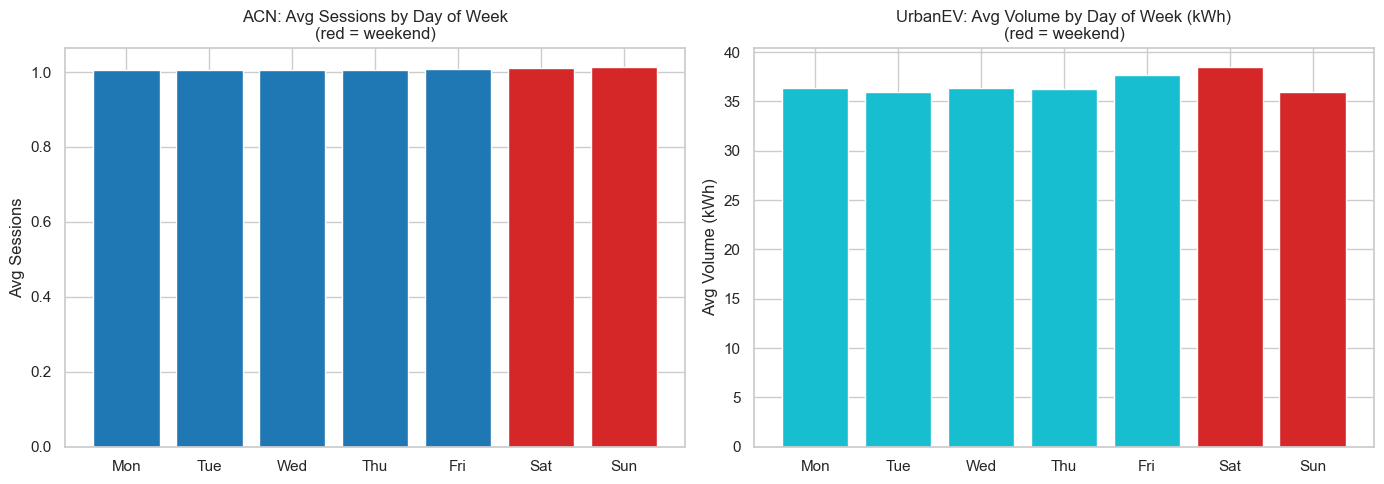

Pricing implication: ACN shows a strong weekday peak (workplace fleet charging).
Weekend discounts can improve off-peak utilisation without sacrificing weekday revenue.


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
day_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

# ACN
acn_dow = acn_h.groupby('dow')['sessions'].mean()
bars = axes[0].bar(acn_dow.index, acn_dow.values,
                   color=[COLORS['peak'] if d >= 5 else COLORS['acn'] for d in acn_dow.index])
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(day_labels)
axes[0].set_title('ACN: Avg Sessions by Day of Week\n(red = weekend)', fontsize=12)
axes[0].set_ylabel('Avg Sessions')

# UrbanEV
uev_dow = uev.groupby('dow')['volume'].mean()
axes[1].bar(uev_dow.index, uev_dow.values,
            color=[COLORS['peak'] if d >= 5 else COLORS['uev'] for d in uev_dow.index])
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_labels)
axes[1].set_title('UrbanEV: Avg Volume by Day of Week (kWh)\n(red = weekend)', fontsize=12)
axes[1].set_ylabel('Avg Volume (kWh)')

plt.tight_layout()
plt.savefig(OUT_FIG / 'eda_weekday_weekend.png', dpi=150)
plt.show()
print('Pricing implication: ACN shows a strong weekday peak (workplace fleet charging).\nWeekend discounts can improve off-peak utilisation without sacrificing weekday revenue.')

## 3. Utilisation Distribution: Peak vs Shoulder vs Off-Peak

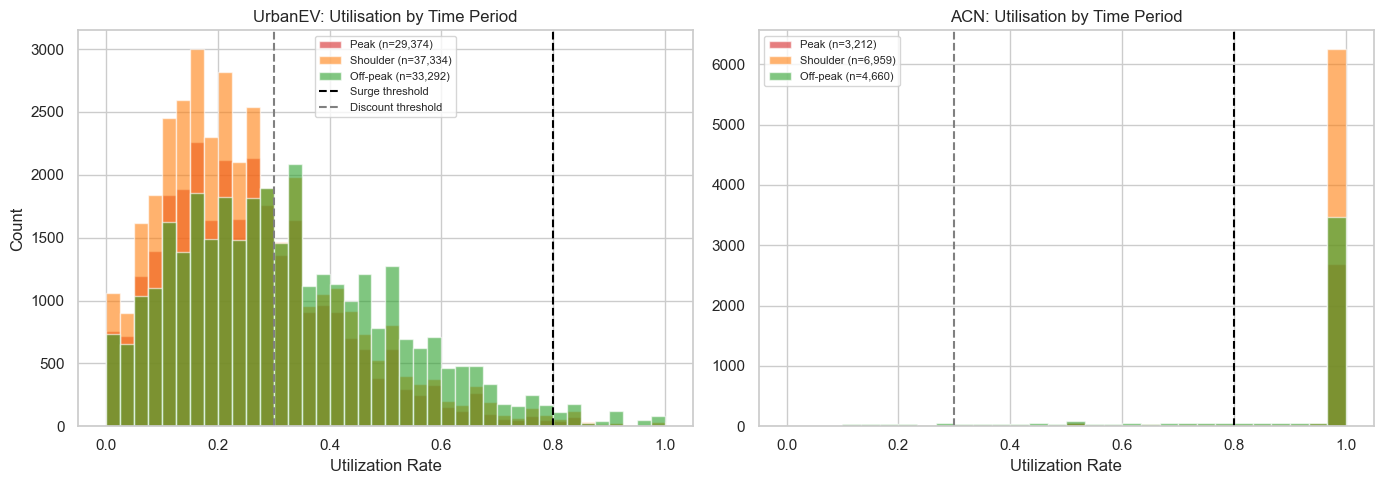

Peak      : surge-eligible 0.7% | discount-eligible 65.3%
Shoulder  : surge-eligible 0.8% | discount-eligible 66.8%
Off-peak  : surge-eligible 1.7% | discount-eligible 50.2%


In [20]:
from features import PEAK_HOURS, OFF_PEAK_HOURS

def label_period(h):
    if h in PEAK_HOURS: return 'Peak'
    if h in OFF_PEAK_HOURS: return 'Off-peak'
    return 'Shoulder'

uev['period_label'] = uev['hour'].apply(label_period)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# UrbanEV utilisation by period
period_order = ['Peak', 'Shoulder', 'Off-peak']
period_colors = [COLORS['peak'], COLORS['shoulder'], COLORS['off_peak']]
uev_sample = uev[uev['utilization_rate'].notna()].sample(100000, random_state=42)
for i, (period, color) in enumerate(zip(period_order, period_colors)):
    data = uev_sample[uev_sample['period_label'] == period]['utilization_rate']
    axes[0].hist(data, bins=40, alpha=0.6, color=color, label=f'{period} (n={len(data):,})')
axes[0].axvline(0.8, color='black', linestyle='--', lw=1.5, label='Surge threshold')
axes[0].axvline(0.3, color='grey', linestyle='--', lw=1.5, label='Discount threshold')
axes[0].set_title('UrbanEV: Utilisation by Time Period', fontsize=12)
axes[0].set_xlabel('Utilization Rate')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8)

# ACN
acn_h['period_label'] = acn_h['hour'].apply(label_period)
for i, (period, color) in enumerate(zip(period_order, period_colors)):
    data = acn_h[acn_h['period_label'] == period]['utilization_rate'].dropna()
    axes[1].hist(data, bins=30, alpha=0.6, color=color, label=f'{period} (n={len(data):,})')
axes[1].axvline(0.8, color='black', linestyle='--', lw=1.5)
axes[1].axvline(0.3, color='grey', linestyle='--', lw=1.5)
axes[1].set_title('ACN: Utilisation by Time Period', fontsize=12)
axes[1].set_xlabel('Utilization Rate')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_FIG / 'eda_utilisation_by_period.png', dpi=150)
plt.show()

# Quantify
for p in period_order:
    frac_surge = (uev_sample[uev_sample['period_label']==p]['utilization_rate'] > 0.8).mean()
    frac_disc  = (uev_sample[uev_sample['period_label']==p]['utilization_rate'] < 0.3).mean()
    print(f'{p:10}: surge-eligible {frac_surge:.1%} | discount-eligible {frac_disc:.1%}')

## 4. CBD vs Non-CBD Demand (UrbanEV Spatial Pattern)

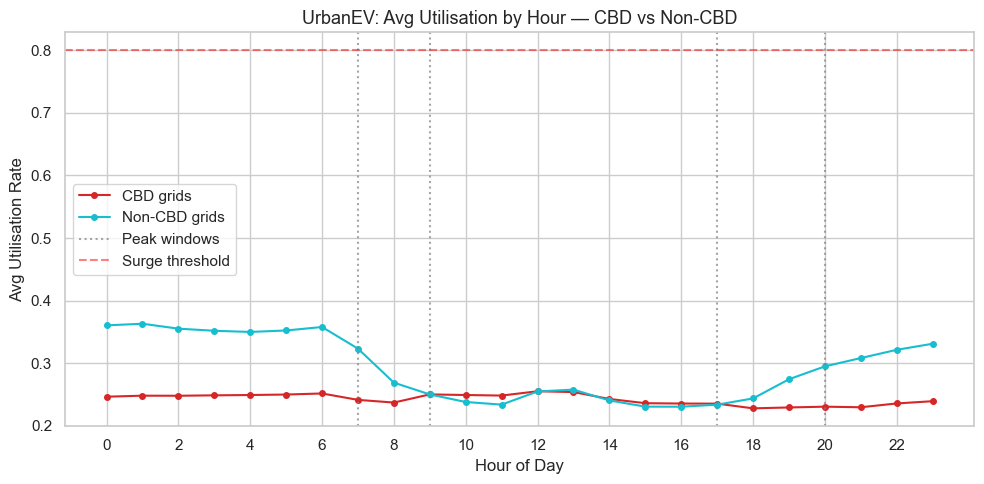

Pricing implication: CBD grids exhibit sharper peaks and higher sustained utilisation,
suggesting location-specific surge pricing can yield higher marginal revenue there.


In [21]:
fig, ax = plt.subplots(figsize=(10, 5))

for cbd, label, color in [(1, 'CBD grids', COLORS['peak']), (0, 'Non-CBD grids', COLORS['uev'])]:
    sub = uev[uev['CBD'] == cbd].groupby('hour')['utilization_rate'].mean()
    ax.plot(sub.index, sub.values, marker='o', markersize=4, label=label, color=color)

ax.axvline(7, color='grey', linestyle=':', alpha=0.7)
ax.axvline(9, color='grey', linestyle=':', alpha=0.7)
ax.axvline(17, color='grey', linestyle=':', alpha=0.7)
ax.axvline(20, color='grey', linestyle=':', alpha=0.7, label='Peak windows')
ax.axhline(0.8, color='red', linestyle='--', alpha=0.5, label='Surge threshold')
ax.set_title('UrbanEV: Avg Utilisation by Hour — CBD vs Non-CBD', fontsize=13)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Avg Utilisation Rate')
ax.set_xticks(range(0, 24, 2))
ax.legend()
plt.tight_layout()
plt.savefig(OUT_FIG / 'eda_cbd_vs_noncbd.png', dpi=150)
plt.show()
print('Pricing implication: CBD grids exhibit sharper peaks and higher sustained utilisation,\nsuggesting location-specific surge pricing can yield higher marginal revenue there.')

## 5. Price–Demand Relationship (UrbanEV Elasticity Preview)

/var/folders/q5/qzzxzszs1194f6vdymzlkyqc0000gn/T/ipykernel_31212/1093422890.py:38: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/q5/qzzxzszs1194f6vdymzlkyqc0000gn/T/ipykernel_31212/1093422890.py:39: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.savefig(OUT_FIG / 'eda_price_elasticity.png', dpi=150)
/Users/prnb/Desktop/socbiz/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


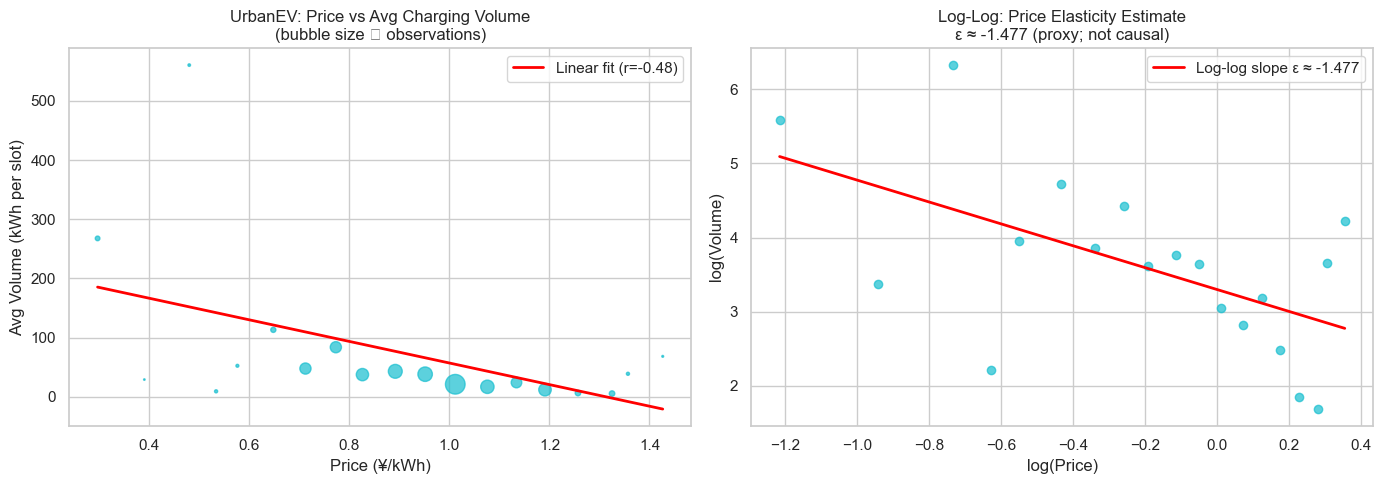

Estimated price elasticity (binned log-log): ε ≈ -1.477
Assumption: this is an associative proxy from UrbanEV ¥ data.
It will parameterise the tariff agent's demand response model.
Caution: this is NOT a causal INR elasticity estimate.


In [22]:
import warnings
from scipy import stats

sub = uev[['price','volume','hour','CBD']].dropna()
sub = sub[(sub['price'] > 0) & (sub['volume'] > 0)]

# Bin prices and compute avg volume per bin
sub['price_bin'] = pd.cut(sub['price'], bins=20)
binned = sub.groupby('price_bin', observed=True).agg(
    mean_price=('price','mean'),
    mean_volume=('volume','mean'),
    n=('volume','count')
).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(binned['mean_price'], binned['mean_volume'],
                s=binned['n']/binned['n'].max()*200, alpha=0.7, color=COLORS['uev'])
m, b, r, p, se = stats.linregress(binned['mean_price'], binned['mean_volume'])
xr = np.linspace(binned['mean_price'].min(), binned['mean_price'].max(), 100)
axes[0].plot(xr, m*xr+b, color='red', lw=2, label=f'Linear fit (r={r:.2f})')
axes[0].set_title('UrbanEV: Price vs Avg Charging Volume\n(bubble size ∝ observations)', fontsize=12)
axes[0].set_xlabel('Price (¥/kWh)')
axes[0].set_ylabel('Avg Volume (kWh per slot)')
axes[0].legend()

# Log-log for elasticity
log_p = np.log(binned['mean_price'])
log_v = np.log(binned['mean_volume'])
m2, b2, r2, p2, _ = stats.linregress(log_p, log_v)
axes[1].scatter(log_p, log_v, alpha=0.7, color=COLORS['uev'])
axes[1].plot(log_p, m2*log_p+b2, color='red', lw=2, label=f'Log-log slope ε ≈ {m2:.3f}')
axes[1].set_title(f'Log-Log: Price Elasticity Estimate\nε ≈ {m2:.3f} (proxy; not causal)', fontsize=12)
axes[1].set_xlabel('log(Price)')
axes[1].set_ylabel('log(Volume)')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_FIG / 'eda_price_elasticity.png', dpi=150)
plt.show()

print(f'Estimated price elasticity (binned log-log): ε ≈ {m2:.3f}')
print('Assumption: this is an associative proxy from UrbanEV ¥ data.')
print('It will parameterise the tariff agent\'s demand response model.')
print('Caution: this is NOT a causal INR elasticity estimate.')

## 6. Long-Run Demand Trend (UrbanEV)

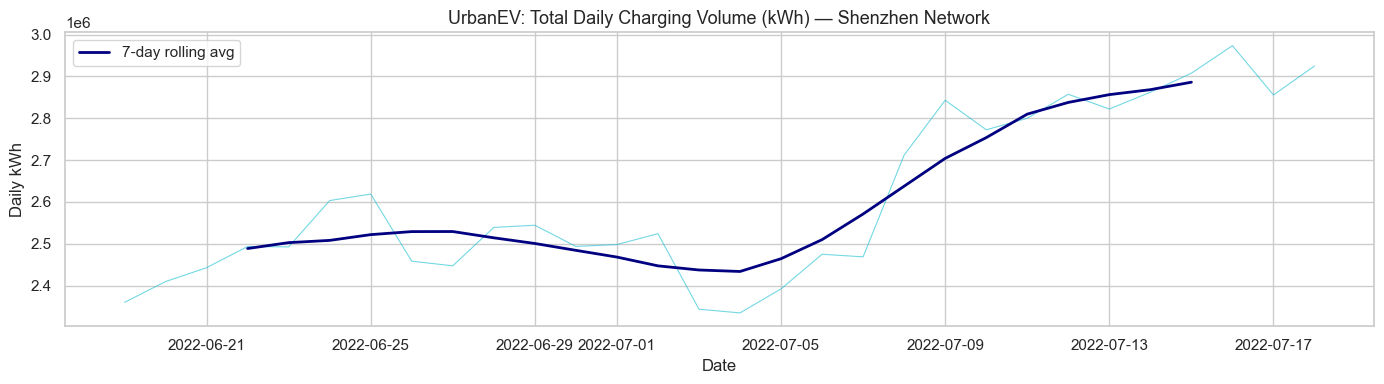

Pricing implication: Upward long-run trend means demand forecasting models must account for non-stationarity.


In [23]:
daily_vol = uev.groupby('datetime')['volume'].sum().reset_index()
daily_vol = daily_vol.set_index('datetime').resample('D')['volume'].sum()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_vol.index, daily_vol.values, alpha=0.6, color=COLORS['uev'], lw=0.8)
roll = daily_vol.rolling(7, center=True).mean()
ax.plot(roll.index, roll.values, color='navy', lw=2, label='7-day rolling avg')
ax.set_title('UrbanEV: Total Daily Charging Volume (kWh) — Shenzhen Network', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Daily kWh')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_FIG / 'eda_daily_volume_trend.png', dpi=150)
plt.show()
print('Pricing implication: Upward long-run trend means demand forecasting models must account for non-stationarity.')

## 7. Top Congested vs Underutilised Stations (ACN)

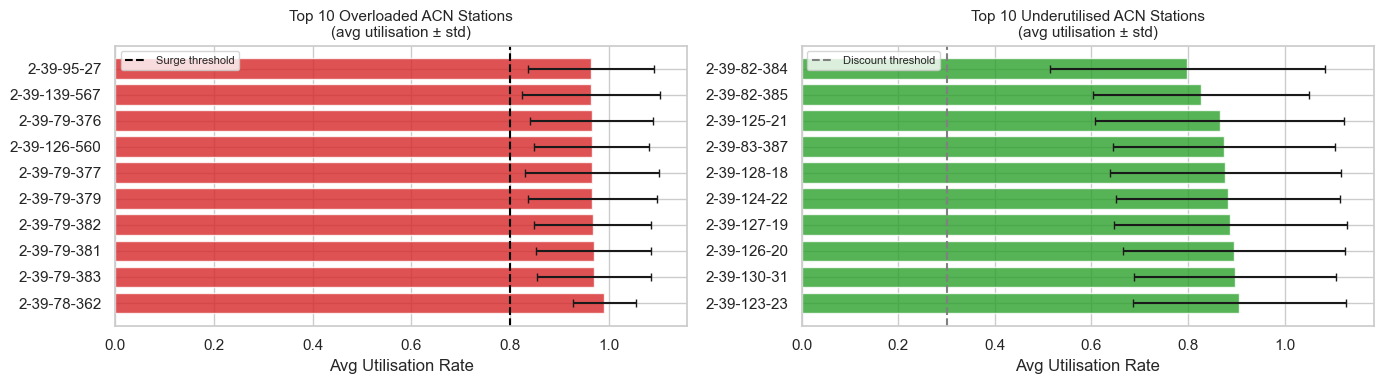

Pricing implication: Persistent over/under-utilisation by station supports station-level tariff differentiation rather than a single network-wide tariff.


In [24]:
station_util = acn_h.groupby('stationID')['utilization_rate'].agg(['mean','std']).sort_values('mean', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

top10 = station_util.head(10)
axes[0].barh(top10.index.astype(str), top10['mean'], xerr=top10['std'],
             color=COLORS['peak'], alpha=0.8, capsize=3)
axes[0].axvline(0.8, color='black', linestyle='--', lw=1.5, label='Surge threshold')
axes[0].set_title('Top 10 Overloaded ACN Stations\n(avg utilisation ± std)', fontsize=11)
axes[0].set_xlabel('Avg Utilisation Rate')
axes[0].legend(fontsize=8)

bot10 = station_util.tail(10)
axes[1].barh(bot10.index.astype(str), bot10['mean'], xerr=bot10['std'],
             color=COLORS['off_peak'], alpha=0.8, capsize=3)
axes[1].axvline(0.3, color='grey', linestyle='--', lw=1.5, label='Discount threshold')
axes[1].set_title('Top 10 Underutilised ACN Stations\n(avg utilisation ± std)', fontsize=11)
axes[1].set_xlabel('Avg Utilisation Rate')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_FIG / 'eda_station_utilisation.png', dpi=150)
plt.show()
print('Pricing implication: Persistent over/under-utilisation by station supports station-level tariff differentiation rather than a single network-wide tariff.')

---

# Stage 3: Demand Prediction Agent


# Notebook 03: Demand Prediction Agent

Predicts next-slot charging demand and congestion probability for each station/grid.

**Outputs → `outputs/`:**
- `demand_predictions.csv`: per-slot predicted utilisation, load, congestion probability
- `demand_metrics.csv`: RMSE / MAE / R² for model vs naïve baseline

**Agent design:**
- Primary model: `HistGradientBoostingRegressor/Classifier` (sklearn) — handles NaN natively, no native wheels required
- Baseline: seasonal-naïve (mean of same hour × day-of-week)
- Strict time-based train/test split (no data leakage)
- Separate models for ACN and UrbanEV panels

In [25]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..') / 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from agents import DemandPredictionAgent, select_features_urbanev, select_features_acn
from features import BASELINE_TARIFF

OUT_DATA = Path('..') / 'data_processed'
OUTPUTS  = Path('..') / 'outputs'
OUT_FIG  = OUTPUTS / 'figures'
OUTPUTS.mkdir(exist_ok=True)
OUT_FIG.mkdir(exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
print('Ready')

Ready


## 1. UrbanEV — Train/Test Split and Feature Matrix

In [26]:
uev = pd.read_parquet(OUT_DATA / 'urbanev_featured.parquet')
uev['datetime'] = pd.to_datetime(uev['datetime'])

# Strict time split: last 20% of timestamps = test
ts_sorted = sorted(uev['timestamp'].unique())
split_idx = int(len(ts_sorted) * 0.8)
ts_train = set(ts_sorted[:split_idx])
ts_test  = set(ts_sorted[split_idx:])

uev_train = uev[uev['timestamp'].isin(ts_train)].copy()
uev_test  = uev[uev['timestamp'].isin(ts_test)].copy()
print(f'Train rows: {len(uev_train):,}  ({uev_train["datetime"].min()} → {uev_train["datetime"].max()})')
print(f'Test rows : {len(uev_test):,}  ({uev_test["datetime"].min()} → {uev_test["datetime"].max()})')

Train rows: 1,707,264  (2022-06-19 00:00:00 → 2022-07-12 23:55:00)
Test rows : 426,816  (2022-07-13 00:00:00 → 2022-07-18 23:55:00)


In [27]:
feat_cols = select_features_urbanev(uev)
print(f'Feature columns ({len(feat_cols)}): {feat_cols}')

# Drop rows where targets are NaN
uev_tr = uev_train.dropna(subset=['utilization_rate','volume','congested'])
uev_te = uev_test.dropna(subset=['utilization_rate','volume','congested'])

X_tr = uev_tr[feat_cols]
X_te = uev_te[feat_cols]
y_util_tr, y_util_te = uev_tr['utilization_rate'], uev_te['utilization_rate']
y_load_tr, y_load_te = uev_tr['volume'], uev_te['volume']
y_cong_tr, y_cong_te = uev_tr['congested'], uev_te['congested']

print(f'X_train: {X_tr.shape}, X_test: {X_te.shape}')
print(f'Congestion base rate (train): {y_cong_tr.mean():.2%}')

Feature columns (23): ['hour', 'dow', 'weekend', 'is_peak', 'is_off_peak', 'count', 'fast_count', 'slow_count', 'area', 'CBD', 'lag_1_occupancy', 'lag_12_occupancy', 'lag_288_occupancy', 'lag_1_volume', 'lag_12_volume', 'lag_1_utilization_rate', 'lag_12_utilization_rate', 'lag_288_utilization_rate', 'roll_2h_occupancy', 'roll_2h_volume', 'roll_2h_utilization_rate', 'lag_1_price', 'roll_2h_price']
X_train: (1707264, 23), X_test: (426816, 23)
Congestion base rate (train): 1.02%


## 2. UrbanEV — Fit Demand Agent

In [28]:
uev_agent = DemandPredictionAgent()
uev_agent.fit(X_tr, y_util_tr, y_load_tr, y_cong_tr)
print('UrbanEV agent fitted.')

UrbanEV agent fitted.


In [29]:
# Predict on test set
uev_preds = uev_agent.predict(X_te)

# Naïve baseline: mean of same hour+dow in train
uev_te_aug = uev_te.copy()
naive_util = DemandPredictionAgent.naive_baseline(uev_tr, 'utilization_rate')
naive_load = DemandPredictionAgent.naive_baseline(uev_tr, 'volume')

# Evaluate
uev_metrics = []
uev_metrics.append(uev_agent.evaluate(y_util_te, uev_preds['pred_utilization'], 'HGB Utilization'))
uev_metrics.append(uev_agent.evaluate(y_load_te, uev_preds['pred_load'], 'HGB Load'))
uev_metrics.append(uev_agent.evaluate(y_util_te,
    DemandPredictionAgent.naive_baseline(uev_tr.assign(hour=uev_tr['hour'], dow=uev_tr['dow']), 'utilization_rate')[:len(y_util_te)] if False else
    uev_te[['hour','dow']].merge(uev_tr.groupby(['hour','dow'])['utilization_rate'].mean().reset_index(), on=['hour','dow'], how='left')['utilization_rate'].values,
    'Naive Baseline Utilization'))
uev_metrics.append(uev_agent.evaluate(y_load_te,
    uev_te[['hour','dow']].merge(uev_tr.groupby(['hour','dow'])['volume'].mean().reset_index(), on=['hour','dow'], how='left')['volume'].values,
    'Naive Baseline Load'))

uev_metrics_df = pd.DataFrame(uev_metrics)
print('=== UrbanEV Model Metrics ===')
print(uev_metrics_df.to_string(index=False))

=== UrbanEV Model Metrics ===
                     label       RMSE       MAE       R2
           HGB Utilization   0.014677  0.005623 0.993113
                  HGB Load   6.866034  1.799261 0.995919
Naive Baseline Utilization   0.172386  0.134027 0.049813
       Naive Baseline Load 106.985067 48.919147 0.009245


## 3. ACN — Train/Test and Fit

In [30]:
acn_h = pd.read_parquet(OUT_DATA / 'acn_station_hour.parquet')
acn_h['slot'] = pd.to_datetime(acn_h['slot'], utc=True)

# Time split
slots_sorted = sorted(acn_h['slot'].unique())
split_slot = slots_sorted[int(len(slots_sorted)*0.8)]
acn_train = acn_h[acn_h['slot'] < split_slot].copy()
acn_test  = acn_h[acn_h['slot'] >= split_slot].copy()
print(f'ACN Train: {len(acn_train):,} rows | Test: {len(acn_test):,} rows')

feat_acn = select_features_acn(acn_h)
print(f'ACN features: {feat_acn}')

acn_tr_clean = acn_train.dropna(subset=['utilization_rate','sessions'])
acn_te_clean = acn_test.dropna(subset=['utilization_rate','sessions'])

acn_tr_clean = acn_tr_clean.copy()
acn_te_clean = acn_te_clean.copy()
acn_tr_clean['congested'] = (acn_tr_clean['utilization_rate'] > 0.8).astype(int)
acn_te_clean['congested'] = (acn_te_clean['utilization_rate'] > 0.8).astype(int)

acn_agent = DemandPredictionAgent(target_load='sessions')
acn_agent.fit(
    acn_tr_clean[feat_acn],
    acn_tr_clean['utilization_rate'],
    acn_tr_clean['sessions'],
    acn_tr_clean['congested'],
)
acn_preds = acn_agent.predict(acn_te_clean[feat_acn])

acn_metrics = []
acn_metrics.append(acn_agent.evaluate(acn_te_clean['utilization_rate'], acn_preds['pred_utilization'], 'HGB Utilization (ACN)'))
acn_metrics.append(acn_agent.evaluate(acn_te_clean['sessions'], acn_preds['pred_load'], 'HGB Sessions (ACN)'))
naive_u = acn_te_clean[['hour','dow']].merge(acn_tr_clean.groupby(['hour','dow'])['utilization_rate'].mean().reset_index(),on=['hour','dow'],how='left')['utilization_rate'].values
acn_metrics.append(acn_agent.evaluate(acn_te_clean['utilization_rate'], naive_u, 'Naive Baseline (ACN)'))

acn_metrics_df = pd.DataFrame(acn_metrics)
print('=== ACN Model Metrics ===')
print(acn_metrics_df.to_string(index=False))

ACN Train: 12,140 rows | Test: 2,699 rows
ACN features: ['hour', 'dow', 'weekend', 'is_peak', 'is_off_peak', 'lag_1h_sessions', 'lag_24h_sessions', 'rolling_7d_sessions']


=== ACN Model Metrics ===
                label     RMSE      MAE        R2
HGB Utilization (ACN) 0.176502 0.105991  0.061883
   HGB Sessions (ACN) 0.093112 0.013813 -0.021396
 Naive Baseline (ACN) 0.176819 0.105086  0.058503


## 4. Visualise Predictions

<>:34: SyntaxWarning: invalid escape sequence '\('
<>:34: SyntaxWarning: invalid escape sequence '\('
/var/folders/q5/qzzxzszs1194f6vdymzlkyqc0000gn/T/ipykernel_31260/2857195968.py:34: SyntaxWarning: invalid escape sequence '\('
  axes[1,1].set_xticklabels(hgb['label'].str.replace(' \(ACN\)','',regex=True), rotation=20, ha='right', fontsize=9)


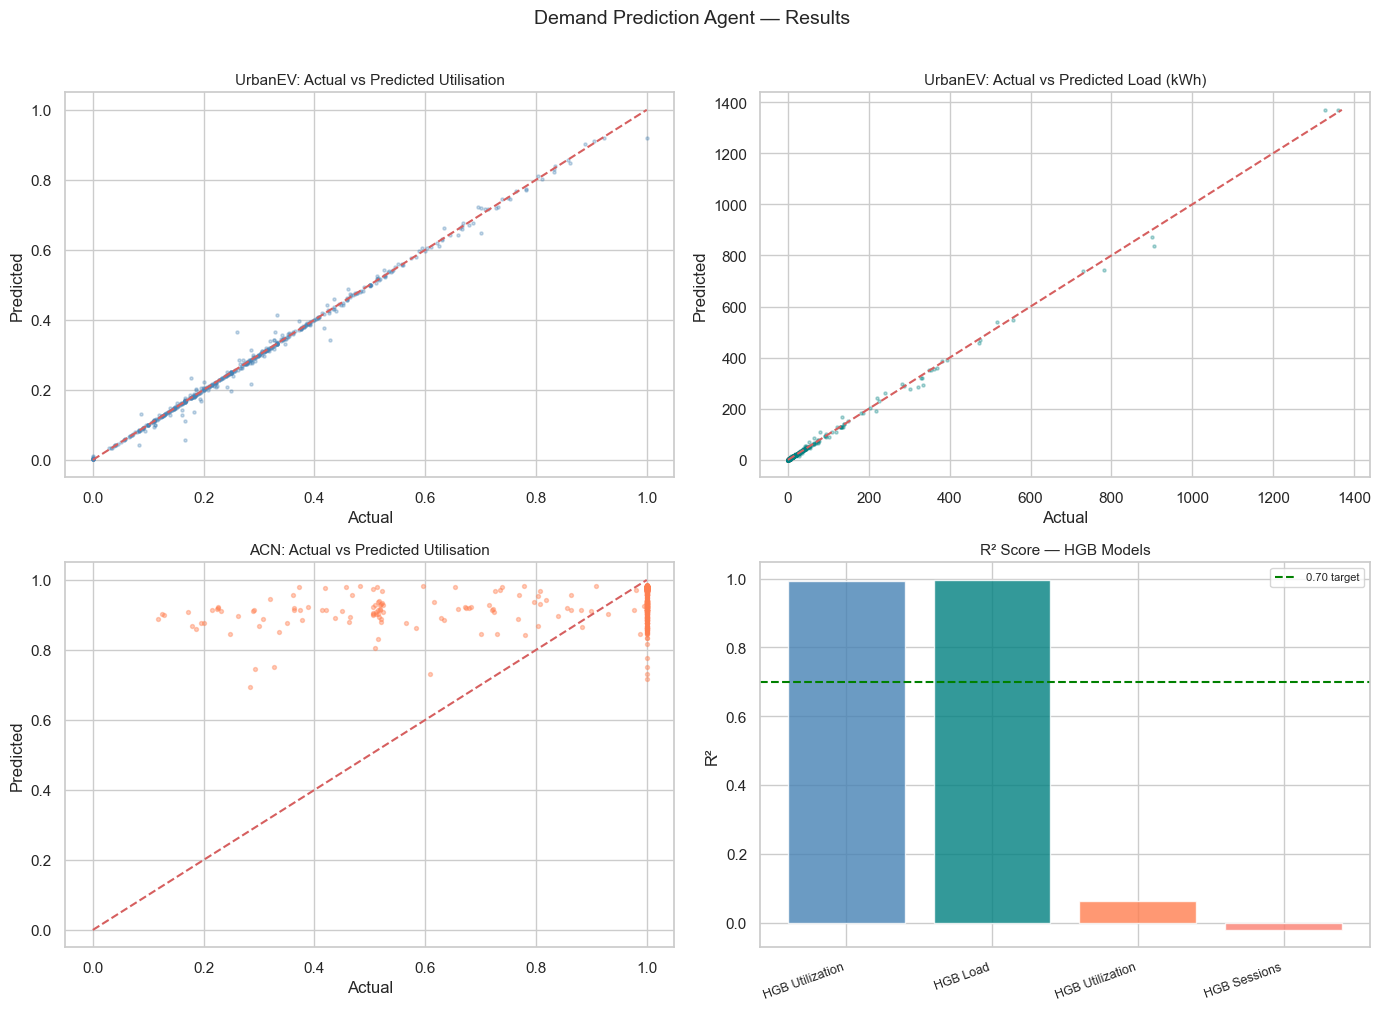

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# UrbanEV utilisation: actual vs predicted (sample)
n = min(500, len(uev_preds))
idx = np.linspace(0, len(uev_preds)-1, n).astype(int)
axes[0,0].scatter(y_util_te.values[idx], uev_preds['pred_utilization'].values[idx],
                  alpha=0.3, s=5, color='steelblue')
axes[0,0].plot([0,1],[0,1], 'r--', lw=1.5)
axes[0,0].set_title('UrbanEV: Actual vs Predicted Utilisation', fontsize=11)
axes[0,0].set_xlabel('Actual'); axes[0,0].set_ylabel('Predicted')

# UrbanEV load
axes[0,1].scatter(y_load_te.values[idx], uev_preds['pred_load'].values[idx],
                  alpha=0.3, s=5, color='teal')
mx = max(y_load_te.values[idx].max(), uev_preds['pred_load'].values[idx].max())
axes[0,1].plot([0,mx],[0,mx], 'r--', lw=1.5)
axes[0,1].set_title('UrbanEV: Actual vs Predicted Load (kWh)', fontsize=11)
axes[0,1].set_xlabel('Actual'); axes[0,1].set_ylabel('Predicted')

# ACN utilisation
n2 = min(500, len(acn_preds))
axes[1,0].scatter(acn_te_clean['utilization_rate'].values[:n2], acn_preds['pred_utilization'].values[:n2],
                  alpha=0.4, s=8, color='coral')
axes[1,0].plot([0,1],[0,1], 'r--', lw=1.5)
axes[1,0].set_title('ACN: Actual vs Predicted Utilisation', fontsize=11)
axes[1,0].set_xlabel('Actual'); axes[1,0].set_ylabel('Predicted')

# Metrics bar chart
all_metrics = pd.concat([uev_metrics_df, acn_metrics_df])
hgb = all_metrics[all_metrics['label'].str.startswith('HGB')]
x = np.arange(len(hgb))
axes[1,1].bar(x, hgb['R2'], color=['steelblue','teal','coral','salmon'][:len(hgb)], alpha=0.8)
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(hgb['label'].str.replace(' \(ACN\)','',regex=True), rotation=20, ha='right', fontsize=9)
axes[1,1].set_title('R² Score — HGB Models', fontsize=11)
axes[1,1].set_ylabel('R²')
axes[1,1].axhline(0.7, color='green', linestyle='--', lw=1.5, label='0.70 target')
axes[1,1].legend(fontsize=8)

plt.suptitle('Demand Prediction Agent — Results', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUT_FIG / 'demand_agent_results.png', dpi=150)
plt.show()

## 5. Export Outputs

In [32]:
# Demand predictions CSV (UrbanEV test set)
uev_out = uev_te[['timestamp','grid_id','datetime','hour','dow',
                   'utilization_rate','volume','congested']].copy().reset_index(drop=True)
uev_out = pd.concat([uev_out, uev_preds.reset_index(drop=True)], axis=1)
uev_out['dataset'] = 'urbanev'

# ACN predictions
acn_out = acn_te_clean[['stationID','slot','hour','dow',
                         'utilization_rate','sessions','congested']].copy().reset_index(drop=True)
acn_p = acn_preds.reset_index(drop=True)
acn_p.columns = ['pred_utilization','pred_load','pred_congestion_prob']
acn_out = pd.concat([acn_out, acn_p], axis=1)
acn_out.rename(columns={'stationID':'entity_id','slot':'datetime','sessions':'volume'}, inplace=True)
acn_out['dataset'] = 'acn'

# Combine
preds_combined = pd.concat([uev_out.rename(columns={'grid_id':'entity_id'}), acn_out],
                           ignore_index=True, sort=False)
preds_combined.to_csv(OUTPUTS / 'demand_predictions.csv', index=False)
print(f'Saved demand_predictions.csv: {len(preds_combined):,} rows')

# Metrics CSV
all_metrics.to_csv(OUTPUTS / 'demand_metrics.csv', index=False)
print('Saved demand_metrics.csv')
print(all_metrics.to_string(index=False))

Saved demand_predictions.csv: 429,513 rows
Saved demand_metrics.csv
                     label       RMSE       MAE        R2
           HGB Utilization   0.014677  0.005623  0.993113
                  HGB Load   6.866034  1.799261  0.995919
Naive Baseline Utilization   0.172386  0.134027  0.049813
       Naive Baseline Load 106.985067 48.919147  0.009245
     HGB Utilization (ACN)   0.176502  0.105991  0.061883
        HGB Sessions (ACN)   0.093112  0.013813 -0.021396
      Naive Baseline (ACN)   0.176819  0.105086  0.058503


---

# Stage 4: Tariff Pricing Agent


# Notebook 04: Tariff Pricing Agent

Translates demand forecasts into optimal dynamic per-kWh tariffs.

**Two pricing policies:**
1. **Rule-based** — transparent surge/discount thresholds (PS-aligned): surge when util > 80%, discount when util < 30%
2. **Optimisation-based** — maximises expected revenue `p × D(p)` subject to a congestion penalty, where `D(p) = D₀ × (p/p₀)^ε` using the estimated elasticity

**Baseline**: ₹15/kWh fixed tariff (PS-specified).

**Key documented assumption**: elasticity ε estimated from UrbanEV ¥ data is used as an order-of-magnitude proxy for INR demand response. This bridges the two datasets but is not a calibrated market-specific estimate.

**Outputs → `outputs/`:**
- `tariff_recommendations.csv`: per slot — util, rule tariff, optimal tariff, expected revenue vs baseline
- `tariff_metrics.csv`: Revenue Gain %, Charger Utilisation Rate, Off-Peak Uplift

In [33]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..') / 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from agents import TariffPricingAgent, estimate_elasticity
from features import BASELINE_TARIFF, SURGE_THRESHOLD, DISCOUNT_THRESHOLD
from metrics import revenue_gain_pct, off_peak_uplift

OUT_DATA = Path('..') / 'data_processed'
OUTPUTS  = Path('..') / 'outputs'
OUT_FIG  = OUTPUTS / 'figures'

sns.set_theme(style='whitegrid', palette='muted')
print('Ready')

Ready


## 1. Estimate Price Elasticity from UrbanEV

In [34]:
uev = pd.read_parquet(OUT_DATA / 'urbanev_featured.parquet')
uev['datetime'] = pd.to_datetime(uev['datetime'])

elasticity = estimate_elasticity(uev, price_col='price', demand_col='volume')
print(f'\nElasticity used by pricing agent: ε = {elasticity:.4f}')
print('Interpretation: a 10% increase in price is associated with a',
      f'{abs(elasticity)*10:.1f}% decrease in volume (log-log OLS estimate).')

Estimated price elasticity (log-log OLS): -2.0188
  Note: proxy estimate from UrbanEV ¥ data; not a causal INR elasticity.

Elasticity used by pricing agent: ε = -2.0188
Interpretation: a 10% increase in price is associated with a 20.2% decrease in volume (log-log OLS estimate).


## 2. Apply Pricing Policies to Demand Predictions

In [35]:
preds = pd.read_csv(OUTPUTS / 'demand_predictions.csv')
print(f'Predictions loaded: {preds.shape}')
print(f'Datasets: {preds["dataset"].value_counts().to_dict()}')
preds.head(3)

Predictions loaded: (429513, 12)
Datasets: {'urbanev': 426816, 'acn': 2697}


/var/folders/q5/qzzxzszs1194f6vdymzlkyqc0000gn/T/ipykernel_31374/2703316937.py:1: DtypeWarning: Columns (0: entity_id) have mixed types. Specify dtype option on import or set low_memory=False.
  preds = pd.read_csv(OUTPUTS / 'demand_predictions.csv')


,timestamp,entity_id,datetime,hour,dow,utilization_rate,volume,congested,pred_utilization,pred_load,pred_congestion_prob,dataset
0,6913.0,1000,2022-07-13 00:00:00,0,2,0.341969,25.375000,0,0.343624,25.632015,0.000002,urbanev
1,6914.0,1000,2022-07-13 00:05:00,0,2,0.347150,25.573333,0,0.343624,25.602964,0.000002,urbanev
2,6915.0,1000,2022-07-13 00:10:00,0,2,0.347150,25.666667,0,0.346563,25.602964,0.000002,urbanev


In [36]:
agent = TariffPricingAgent(elasticity=elasticity)

# Apply to all predictions
recs = agent.recommend(preds, demand_col='pred_load')

print('Tariff distribution (rule-based):')
print(recs['tariff_rule'].describe().round(2))
print('\nTariff distribution (optimised):')
print(recs['tariff_optimal'].describe().round(2))

Tariff distribution (rule-based):
count    429513.00
mean         13.58
std           1.90
min           9.00
25%          12.33
50%          14.24
75%          15.00
max          23.91
Name: tariff_rule, dtype: float64

Tariff distribution (optimised):
count    429513.00
mean          9.77
std           1.45
min           9.00
25%           9.00
50%           9.00
75%           9.89
max          24.00
Name: tariff_optimal, dtype: float64


## 3. Revenue Gain Analysis

In [37]:
# Fix column name after recommend() (it prefixes rev_ for both)
# re-derive cleanly
recs['rev_rule'] = recs['pred_load'] * recs['tariff_rule']
recs['rev_optimal'] = recs['pred_load'] * recs['tariff_optimal']
recs['rev_baseline'] = recs['pred_load'] * BASELINE_TARIFF

# Aggregate by dataset
for ds in ['urbanev', 'acn']:
    sub = recs[recs['dataset'] == ds]
    total_base = sub['rev_baseline'].sum()
    gain_rule = revenue_gain_pct(sub['rev_rule'].sum(), total_base)
    gain_opt  = revenue_gain_pct(sub['rev_optimal'].sum(), total_base)
    print(f'{ds.upper()}:')
    print(f'  Baseline revenue  : {total_base:,.1f}')
    print(f'  Revenue Gain (rule-based)  : {gain_rule:+.2f}%')
    print(f'  Revenue Gain (optimised)   : {gain_opt:+.2f}%')

URBANEV:
  Baseline revenue  : 260,077,087.5
  Revenue Gain (rule-based)  : -1.54%
  Revenue Gain (optimised)   : -37.20%
ACN:
  Baseline revenue  : 40,760.7
  Revenue Gain (rule-based)  : +41.74%
  Revenue Gain (optimised)   : +8.20%


## 4. Utilisation Before vs After Dynamic Pricing

In [38]:
# Simulated post-pricing utilisation: util scales with demand response
# D_new = D_base * (tariff/15)^ε  =>  util_new = util_old * (D_new/D_base)

eps = elasticity
recs['util_after_rule'] = (recs['pred_utilization'] *
    (recs['tariff_rule'] / BASELINE_TARIFF) ** eps).clip(0, 1)
recs['util_after_opt']  = (recs['pred_utilization'] *
    (recs['tariff_optimal'] / BASELINE_TARIFF) ** eps).clip(0, 1)

# Peak periods
recs['is_peak_flag'] = recs.get('is_peak', recs.get('hour', pd.Series(dtype=float)).isin(range(7,21))).astype(bool) if 'is_peak' in recs.columns else False

print('Utilisation summary (all slots):')
print(f'  Before (predicted)     : {recs["pred_utilization"].mean():.3f}')
print(f'  After rule-based       : {recs["util_after_rule"].mean():.3f}')
print(f'  After optimised        : {recs["util_after_opt"].mean():.3f}')
print(f'\nFraction surge-zone (>80%) before: {(recs["pred_utilization"]>0.8).mean():.1%}')
print(f'Fraction surge-zone (>80%) after rule: {(recs["util_after_rule"]>0.8).mean():.1%}')

Utilisation summary (all slots):
  Before (predicted)     : 0.295
  After rule-based       : 0.324
  After optimised        : 0.630

Fraction surge-zone (>80%) before: 1.7%
Fraction surge-zone (>80%) after rule: 0.0%


## 5. Off-Peak Uplift

In [39]:
uplift_rule = off_peak_uplift(
    recs['pred_load'],
    recs['pred_load'] * (recs['tariff_rule']/BASELINE_TARIFF)**eps,
    recs['pred_utilization']
)
print(f'Off-peak session uplift (rule-based): {uplift_rule:+.3f} kWh/slot avg increase')

Off-peak session uplift (rule-based): +3.787 kWh/slot avg increase


## 6. Tariff Heatmap by Hour & Utilisation

/var/folders/q5/qzzxzszs1194f6vdymzlkyqc0000gn/T/ipykernel_31374/1116110304.py:40: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/q5/qzzxzszs1194f6vdymzlkyqc0000gn/T/ipykernel_31374/1116110304.py:41: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.savefig(OUT_FIG / 'tariff_agent_results.png', dpi=150)
/Users/prnb/Desktop/socbiz/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


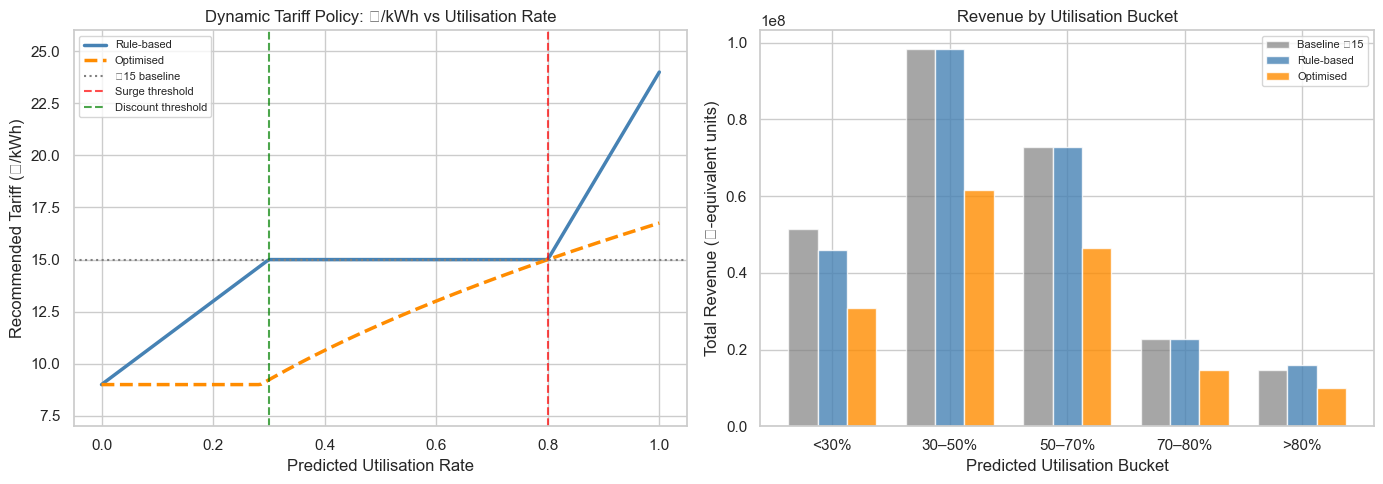

In [40]:
# Rule-based tariff as function of utilisation (deterministic)
util_vals = np.linspace(0, 1, 200)
tariff_curve = [agent.rule_based_tariff(u) for u in util_vals]
opt_curve    = [agent.optimal_tariff(u, 10.0) for u in util_vals]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(util_vals, tariff_curve, lw=2.5, color='steelblue', label='Rule-based')
axes[0].plot(util_vals, opt_curve, lw=2.5, color='darkorange', linestyle='--', label='Optimised')
axes[0].axhline(BASELINE_TARIFF, color='grey', linestyle=':', lw=1.5, label='₹15 baseline')
axes[0].axvline(SURGE_THRESHOLD, color='red', linestyle='--', lw=1.5, alpha=0.7, label='Surge threshold')
axes[0].axvline(DISCOUNT_THRESHOLD, color='green', linestyle='--', lw=1.5, alpha=0.7, label='Discount threshold')
axes[0].set_title('Dynamic Tariff Policy: ₹/kWh vs Utilisation Rate', fontsize=12)
axes[0].set_xlabel('Predicted Utilisation Rate')
axes[0].set_ylabel('Recommended Tariff (₹/kWh)')
axes[0].set_ylim(7, 26)
axes[0].legend(fontsize=8)

# Revenue comparison by utilisation bucket
recs['util_bucket'] = pd.cut(recs['pred_utilization'], bins=[0,0.3,0.5,0.7,0.8,1.0],
                              labels=['<30%','30–50%','50–70%','70–80%','>80%'])
rev_compare = recs.groupby('util_bucket', observed=True).agg(
    rev_base=('rev_baseline','sum'),
    rev_rule=('rev_rule','sum'),
    rev_opt=('rev_optimal','sum'),
).reset_index()

x = np.arange(len(rev_compare))
w = 0.25
axes[1].bar(x-w, rev_compare['rev_base'], w, label='Baseline ₹15', color='grey', alpha=0.7)
axes[1].bar(x,   rev_compare['rev_rule'], w, label='Rule-based', color='steelblue', alpha=0.8)
axes[1].bar(x+w, rev_compare['rev_opt'],  w, label='Optimised', color='darkorange', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(rev_compare['util_bucket'].astype(str))
axes[1].set_title('Revenue by Utilisation Bucket', fontsize=12)
axes[1].set_xlabel('Predicted Utilisation Bucket')
axes[1].set_ylabel('Total Revenue (₹-equivalent units)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_FIG / 'tariff_agent_results.png', dpi=150)
plt.show()

## 7. Export Outputs

In [41]:
recs.to_csv(OUTPUTS / 'tariff_recommendations.csv', index=False)
print(f'Saved tariff_recommendations.csv: {len(recs):,} rows')

# Metrics summary
tariff_metrics = []
for ds in ['urbanev','acn']:
    sub = recs[recs['dataset'] == ds]
    tariff_metrics.append({
        'dataset': ds,
        'baseline_revenue': sub['rev_baseline'].sum(),
        'rule_revenue': sub['rev_rule'].sum(),
        'opt_revenue': sub['rev_optimal'].sum(),
        'revenue_gain_pct_rule': revenue_gain_pct(sub['rev_rule'].sum(), sub['rev_baseline'].sum()),
        'revenue_gain_pct_opt': revenue_gain_pct(sub['rev_optimal'].sum(), sub['rev_baseline'].sum()),
        'mean_util_before': sub['pred_utilization'].mean(),
        'mean_util_after_rule': sub['util_after_rule'].mean(),
        'pct_surge_before': (sub['pred_utilization']>0.8).mean(),
        'pct_surge_after_rule': (sub['util_after_rule']>0.8).mean(),
        'elasticity_used': eps,
    })

pd.DataFrame(tariff_metrics).to_csv(OUTPUTS / 'tariff_metrics.csv', index=False)
print('Saved tariff_metrics.csv')
pd.DataFrame(tariff_metrics).round(4)

Saved tariff_recommendations.csv: 429,513 rows
Saved tariff_metrics.csv


,dataset,baseline_revenue,rule_revenue,opt_revenue,revenue_gain_pct_rule,revenue_gain_pct_opt,mean_util_before,mean_util_after_rule,pct_surge_before,pct_surge_after_rule,elasticity_used
0,urbanev,2.600771e+08,2.560740e+08,1.633230e+08,-1.5392,-37.2021,0.2908,0.3235,0.0112,0.0,-2.0188
1,acn,4.076070e+04,5.777235e+04,4.410245e+04,41.7354,8.1985,0.9387,0.4726,0.9855,0.0,-2.0188


---

# Stage 5: Monitoring & Learning Agent


# Notebook 05: Monitoring & Learning Agent

Closes the agentic feedback loop: the agent evaluates each pricing decision against simulated operational outcomes and iteratively refines its tariff policy.

**How it works:**
1. A `ChargingEnvironment` simulator acts as the 'live environment' — given a tariff and predicted state, it returns realized demand, utilisation, revenue, congestion penalty, and wait time.
2. A **contextual-bandit / iterative policy** adjusts the tariff multiplier parameters (surge cap, discount floor) based on accumulated reward signal.
3. The loop runs for N episodes; we track all PS-specified monitoring metrics over time.

**Outputs → `outputs/`:**
- `monitoring_metrics.csv`: per-episode Revenue Gain %, Charger Utilisation, Wait Time, Customer Response Rate, Pricing Efficiency Score
- Learning curve figures

In [42]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..') / 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from simulator import ChargingEnvironment
from agents import TariffPricingAgent
from metrics import (revenue_gain_pct, avg_wait_time_reduction,
                     customer_response_rate, pricing_efficiency_score,
                     compile_agent_metrics)
from features import BASELINE_TARIFF, SURGE_THRESHOLD, DISCOUNT_THRESHOLD

OUTPUTS = Path('..') / 'outputs'
OUT_FIG = OUTPUTS / 'figures'

sns.set_theme(style='whitegrid', palette='muted')
np.random.seed(42)
print('Ready')

Ready


## 1. Load Demand Predictions (Agent's Input States)

In [43]:
preds = pd.read_csv(OUTPUTS / 'demand_predictions.csv')
# Use UrbanEV test set as the episodic simulation states
states_df = preds[preds['dataset'] == 'urbanev'].copy()
states_df = states_df.dropna(subset=['pred_utilization','pred_load'])
states_df = states_df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle for episodic sampling
print(f'Simulation states: {len(states_df):,}')

Simulation states: 426,816


/var/folders/q5/qzzxzszs1194f6vdymzlkyqc0000gn/T/ipykernel_31497/1677652168.py:1: DtypeWarning: Columns (0: entity_id) have mixed types. Specify dtype option on import or set low_memory=False.
  preds = pd.read_csv(OUTPUTS / 'demand_predictions.csv')


## 2. Define Learnable Pricing Policy

The policy has two learnable parameters:
- `surge_factor` ∈ [1.0, 1.8]: multiplier applied above the surge threshold
- `discount_factor` ∈ [0.5, 1.0]: multiplier applied below the discount threshold

The feedback loop uses a simple gradient-free hill-climb (coordinate ascent) — clear, reproducible, and directly tracks reward improvement over episodes.

In [44]:
class LearnableTariffPolicy:
    """Tariff policy with learnable surge and discount multipliers."""

    def __init__(self, surge_factor=1.3, discount_factor=0.8):
        self.surge_factor = float(surge_factor)
        self.discount_factor = float(discount_factor)
        self.min_tariff = 9.0
        self.max_tariff = 24.0

    def __call__(self, pred_util: float) -> float:
        if pred_util > SURGE_THRESHOLD:
            t = BASELINE_TARIFF * self.surge_factor
        elif pred_util < DISCOUNT_THRESHOLD:
            t = BASELINE_TARIFF * self.discount_factor
        else:
            # Linear interpolation between discount and surge zones
            frac = (pred_util - DISCOUNT_THRESHOLD) / (SURGE_THRESHOLD - DISCOUNT_THRESHOLD)
            t = BASELINE_TARIFF * (self.discount_factor + frac * (self.surge_factor - self.discount_factor))
        return float(np.clip(t, self.min_tariff, self.max_tariff))

    def clone(self):
        return LearnableTariffPolicy(self.surge_factor, self.discount_factor)


print('Policy defined.')

Policy defined.


## 3. Run Episodic Feedback Loop

In [45]:
def run_episode(policy, env, states_df, batch_size=200, seed=None):
    """Run one evaluation episode over a random batch of states."""
    rng = np.random.default_rng(seed)
    batch_idx = rng.choice(len(states_df), size=batch_size, replace=False)
    batch = states_df.iloc[batch_idx].reset_index(drop=True)

    results = []
    for _, row in batch.iterrows():
        state = {
            'pred_utilization': row['pred_utilization'],
            'baseline_demand': max(row['pred_load'], 0.1),
            'capacity': max(row['pred_load'], 0.1) / max(row['pred_utilization'], 0.01),
        }
        tariff = policy(row['pred_utilization'])
        outcome = env.step(state, tariff)
        outcome['baseline_revenue'] = row['pred_load'] * BASELINE_TARIFF
        outcome['pred_utilization'] = row['pred_utilization']
        results.append(outcome)

    df = pd.DataFrame(results)
    total_rev = df['revenue'].sum()
    baseline_rev = df['baseline_revenue'].sum()
    return {
        'total_reward': df['reward'].sum(),
        'revenue_gain_pct': revenue_gain_pct(total_rev, baseline_rev),
        'mean_realized_util': df['realized_util'].mean(),
        'mean_wait_time': df['wait_time_proxy'].mean(),
        'pricing_efficiency': pricing_efficiency_score(df['revenue'].values,
                                                       df['realized_demand'].values).mean(),
        'surge_factor': getattr(policy, 'surge_factor', float('nan')),
        'discount_factor': getattr(policy, 'discount_factor', float('nan')),
    }


print('Episode runner defined.')

Episode runner defined.


In [46]:
# Estimate elasticity from UrbanEV for the simulator
tariff_metrics = pd.read_csv(OUTPUTS / 'tariff_metrics.csv')
elasticity = float(tariff_metrics['elasticity_used'].iloc[0])
print(f'Using elasticity ε = {elasticity:.4f}')

env = ChargingEnvironment(elasticity=elasticity, noise_std=0.05, seed=42)

# Initial policy
policy = LearnableTariffPolicy(surge_factor=1.3, discount_factor=0.8)

# Baseline (fixed ₹15)
class FixedPolicy:
    def __call__(self, u): return BASELINE_TARIFF

baseline_policy = FixedPolicy()
baseline_ep = run_episode(baseline_policy, env, states_df, batch_size=500, seed=0)
print(f'Baseline episode reward: {baseline_ep["total_reward"]:.2f}')
print(f'Baseline Revenue Gain%: {baseline_ep["revenue_gain_pct"]:+.2f}%')

Using elasticity ε = -2.0188
Baseline episode reward: 290800.38
Baseline Revenue Gain%: -0.25%


In [47]:
N_EPISODES = 40
STEP_SIZES = [0.05, 0.025, 0.01]  # coordinate ascent step sizes
BATCH_SIZE = 300

episode_log = []
best_reward = -np.inf
best_policy = policy.clone()

current_reward = run_episode(policy, env, states_df, BATCH_SIZE, seed=1)['total_reward']

for ep in range(N_EPISODES):
    step = STEP_SIZES[min(ep // 15, len(STEP_SIZES)-1)]

    # Try perturbing surge_factor
    for delta in [step, -step]:
        candidate = policy.clone()
        candidate.surge_factor = float(np.clip(candidate.surge_factor + delta, 1.0, 1.8))
        r = run_episode(candidate, env, states_df, BATCH_SIZE, seed=ep+100)['total_reward']
        if r > current_reward:
            policy = candidate
            current_reward = r
            break

    # Try perturbing discount_factor
    for delta in [step, -step]:
        candidate = policy.clone()
        candidate.discount_factor = float(np.clip(candidate.discount_factor + delta, 0.5, 1.0))
        r = run_episode(candidate, env, states_df, BATCH_SIZE, seed=ep+200)['total_reward']
        if r > current_reward:
            policy = candidate
            current_reward = r
            break

    ep_metrics = run_episode(policy, env, states_df, BATCH_SIZE, seed=ep+300)
    ep_metrics['episode'] = ep + 1
    ep_metrics['step_size'] = step
    episode_log.append(ep_metrics)

    if ep_metrics['total_reward'] > best_reward:
        best_reward = ep_metrics['total_reward']
        best_policy = policy.clone()

    if (ep+1) % 10 == 0:
        print(f'  Episode {ep+1:3d}: reward={ep_metrics["total_reward"]:8.2f} | '
              f'revenue_gain={ep_metrics["revenue_gain_pct"]:+.2f}% | '
              f'surge={policy.surge_factor:.3f} | discount={policy.discount_factor:.3f}')

print(f'\nBest policy: surge_factor={best_policy.surge_factor:.3f}, discount_factor={best_policy.discount_factor:.3f}')
print(f'Best reward: {best_reward:.2f}')

  Episode  10: reward=207801.73 | revenue_gain=+4.46% | surge=1.300 | discount=0.800


  Episode  20: reward=166216.31 | revenue_gain=+7.48% | surge=1.300 | discount=0.825


  Episode  30: reward=212017.13 | revenue_gain=+1.70% | surge=1.300 | discount=0.825


  Episode  40: reward=181461.97 | revenue_gain=+6.64% | surge=1.310 | discount=0.825

Best policy: surge_factor=1.300, discount_factor=0.825
Best reward: 244324.56


## 4. All Monitoring Metrics — Final Evaluation Episode

In [48]:
# Large final evaluation: best learned policy vs baseline
FINAL_BATCH = 1000

# Evaluate baseline
rng = np.random.default_rng(999)
batch_idx = rng.choice(len(states_df), size=FINAL_BATCH, replace=False)
batch = states_df.iloc[batch_idx].reset_index(drop=True)

baseline_outcomes, learned_outcomes = [], []
for _, row in batch.iterrows():
    state = {
        'pred_utilization': row['pred_utilization'],
        'baseline_demand': max(row['pred_load'], 0.1),
        'capacity': max(row['pred_load'], 0.1) / max(row['pred_utilization'], 0.01),
    }
    baseline_outcomes.append(env.step(state, BASELINE_TARIFF))
    learned_tariff = best_policy(row['pred_utilization'])
    learned_outcomes.append(env.step(state, learned_tariff))

b_df = pd.DataFrame(baseline_outcomes)
l_df = pd.DataFrame(learned_outcomes)

print('=== Final Evaluation Metrics ===')
print(f'Revenue Gain % (best policy vs baseline):  {revenue_gain_pct(l_df["revenue"].sum(), b_df["revenue"].sum()):+.2f}%')
print(f'Charger Utilisation — baseline:            {b_df["realized_util"].mean():.3f}')
print(f'Charger Utilisation — learned:             {l_df["realized_util"].mean():.3f}')
print(f'Avg Wait Time — baseline (min):            {b_df["wait_time_proxy"].mean():.3f}')
print(f'Avg Wait Time — learned (min):             {l_df["wait_time_proxy"].mean():.3f}')
print(f'Wait Time Reduction:                       {avg_wait_time_reduction(b_df["wait_time_proxy"].values, l_df["wait_time_proxy"].values):.3f} min')
print(f'Pricing Efficiency (baseline ₹/kWh):       {pricing_efficiency_score(b_df["revenue"].values, b_df["realized_demand"].values).mean():.3f}')
print(f'Pricing Efficiency (learned ₹/kWh):        {pricing_efficiency_score(l_df["revenue"].values, l_df["realized_demand"].values).mean():.3f}')
crr = customer_response_rate(
    b_df['realized_demand'].values, l_df['realized_demand'].values,
    np.full(FINAL_BATCH, BASELINE_TARIFF),
    np.array([best_policy(u) for u in batch['pred_utilization']])
)
print(f'Customer Response Rate (sessions/₹):       {crr:.4f}')

=== Final Evaluation Metrics ===
Revenue Gain % (best policy vs baseline):  +0.67%
Charger Utilisation — baseline:            0.304
Charger Utilisation — learned:             0.352
Avg Wait Time — baseline (min):            0.032
Avg Wait Time — learned (min):             0.000
Wait Time Reduction:                       0.032 min
Pricing Efficiency (baseline ₹/kWh):       15.000
Pricing Efficiency (learned ₹/kWh):        13.427
Customer Response Rate (sessions/₹):       -6.9492


## 5. Learning Curve Visualisations

/var/folders/q5/qzzxzszs1194f6vdymzlkyqc0000gn/T/ipykernel_31497/2785966452.py:39: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/q5/qzzxzszs1194f6vdymzlkyqc0000gn/T/ipykernel_31497/2785966452.py:40: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.savefig(OUT_FIG / 'monitoring_learning_curves.png', dpi=150)


/Users/prnb/Desktop/socbiz/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


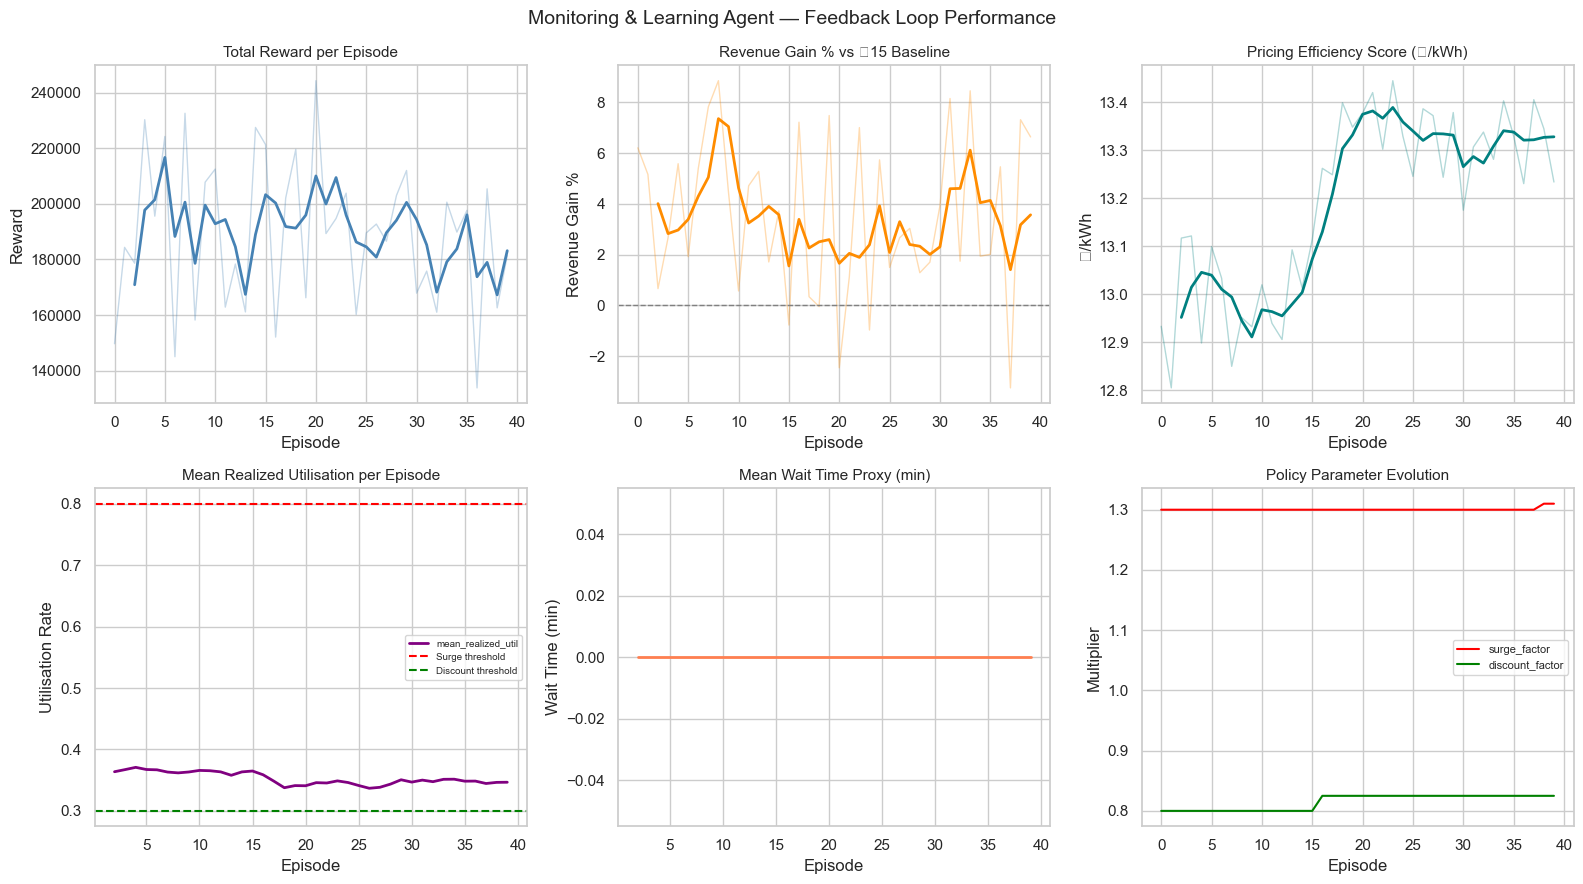

In [49]:
ep_df = pd.DataFrame(episode_log)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

ep_df['total_reward'].rolling(3).mean().plot(ax=axes[0,0], color='steelblue', lw=2)
ep_df['total_reward'].plot(ax=axes[0,0], color='steelblue', alpha=0.3, lw=1)
axes[0,0].set_title('Total Reward per Episode', fontsize=11)
axes[0,0].set_xlabel('Episode'); axes[0,0].set_ylabel('Reward')

ep_df['revenue_gain_pct'].rolling(3).mean().plot(ax=axes[0,1], color='darkorange', lw=2)
ep_df['revenue_gain_pct'].plot(ax=axes[0,1], color='darkorange', alpha=0.3, lw=1)
axes[0,1].axhline(0, color='grey', linestyle='--', lw=1)
axes[0,1].set_title('Revenue Gain % vs ₹15 Baseline', fontsize=11)
axes[0,1].set_xlabel('Episode'); axes[0,1].set_ylabel('Revenue Gain %')

ep_df['pricing_efficiency'].rolling(3).mean().plot(ax=axes[0,2], color='teal', lw=2)
ep_df['pricing_efficiency'].plot(ax=axes[0,2], color='teal', alpha=0.3, lw=1)
axes[0,2].set_title('Pricing Efficiency Score (₹/kWh)', fontsize=11)
axes[0,2].set_xlabel('Episode'); axes[0,2].set_ylabel('₹/kWh')

ep_df['mean_realized_util'].rolling(3).mean().plot(ax=axes[1,0], color='purple', lw=2)
axes[1,0].axhline(SURGE_THRESHOLD, color='red', linestyle='--', lw=1.5, label='Surge threshold')
axes[1,0].axhline(DISCOUNT_THRESHOLD, color='green', linestyle='--', lw=1.5, label='Discount threshold')
axes[1,0].set_title('Mean Realized Utilisation per Episode', fontsize=11)
axes[1,0].set_xlabel('Episode'); axes[1,0].set_ylabel('Utilisation Rate')
axes[1,0].legend(fontsize=7)

ep_df['mean_wait_time'].rolling(3).mean().plot(ax=axes[1,1], color='coral', lw=2)
axes[1,1].set_title('Mean Wait Time Proxy (min)', fontsize=11)
axes[1,1].set_xlabel('Episode'); axes[1,1].set_ylabel('Wait Time (min)')

axes[1,2].plot(ep_df['surge_factor'], label='surge_factor', color='red')
axes[1,2].plot(ep_df['discount_factor'], label='discount_factor', color='green')
axes[1,2].set_title('Policy Parameter Evolution', fontsize=11)
axes[1,2].set_xlabel('Episode'); axes[1,2].set_ylabel('Multiplier')
axes[1,2].legend(fontsize=8)

plt.suptitle('Monitoring & Learning Agent — Feedback Loop Performance', fontsize=14)
plt.tight_layout()
plt.savefig(OUT_FIG / 'monitoring_learning_curves.png', dpi=150)
plt.show()

## 6. Export Monitoring Metrics

In [50]:
ep_df.to_csv(OUTPUTS / 'monitoring_metrics.csv', index=False)
print(f'Saved monitoring_metrics.csv: {len(ep_df)} episodes')

# Final summary metrics
summary = {
    'revenue_gain_pct_final': revenue_gain_pct(l_df['revenue'].sum(), b_df['revenue'].sum()),
    'charger_util_baseline': b_df['realized_util'].mean(),
    'charger_util_learned': l_df['realized_util'].mean(),
    'wait_time_reduction_min': avg_wait_time_reduction(b_df['wait_time_proxy'].values, l_df['wait_time_proxy'].values),
    'pricing_efficiency_baseline': pricing_efficiency_score(b_df['revenue'].values, b_df['realized_demand'].values).mean(),
    'pricing_efficiency_learned': pricing_efficiency_score(l_df['revenue'].values, l_df['realized_demand'].values).mean(),
    'customer_response_rate': crr,
    'best_surge_factor': best_policy.surge_factor,
    'best_discount_factor': best_policy.discount_factor,
    'n_episodes': N_EPISODES,
}
pd.DataFrame([summary]).to_csv(OUTPUTS / 'monitoring_summary.csv', index=False)
print('Saved monitoring_summary.csv')
print('\n=== Final Monitoring Summary ===')
for k, v in summary.items():
    print(f'  {k:45}: {v:.4f}' if isinstance(v, float) else f'  {k:45}: {v}')

Saved monitoring_metrics.csv: 40 episodes
Saved monitoring_summary.csv

=== Final Monitoring Summary ===
  revenue_gain_pct_final                       : 0.6691
  charger_util_baseline                        : 0.3041
  charger_util_learned                         : 0.3521
  wait_time_reduction_min                      : 0.0323
  pricing_efficiency_baseline                  : 15.0000
  pricing_efficiency_learned                   : 13.4266
  customer_response_rate                       : -6.9492
  best_surge_factor                            : 1.3000
  best_discount_factor                         : 0.8250
  n_episodes                                   : 40
